# Spatial Hotspot Analysis on Synthetic Observation Data

This notebook demonstrates a compact workflow for analyzing timestamped spatial observations.

It uses synthetic data and avoids any private, operational, or company-specific context. The goal is to show a clean applied analysis pattern: load observations, aggregate in space and time, visualize spatial concentration, detect unusually active grid cells, and track persistent buildup over time.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Load or generate synthetic observation data

The dataset contains timestamped latitude/longitude observations with a count value. In a real application, the same structure could represent environmental observations, field measurements, incident reports, sensor events, or any other count-like spatial signal.

The notebook first tries to load `sample_observations.csv` from a local `data/` folder. If the file is not available, it generates a small synthetic dataset so the notebook remains fully runnable.


In [2]:
def generate_synthetic_observations(
    n_background: int = 900,
    n_hotspot: int = 550,
    n_secondary: int = 250,
    start_date: str = "2026-01-01",
    n_days: int = 45,
) -> pd.DataFrame:
    """Generate synthetic timestamped spatial observations.

    The data contains one persistent hotspot, one weaker secondary region,
    and diffuse background events. It is designed for demonstration only.
    """

    base_lat, base_lon = 41.88, -87.63

    # Diffuse background around the region.
    background_lat = rng.normal(base_lat, 0.055, n_background)
    background_lon = rng.normal(base_lon, 0.070, n_background)

    # Persistent primary hotspot.
    hotspot_lat = rng.normal(base_lat + 0.015, 0.012, n_hotspot)
    hotspot_lon = rng.normal(base_lon + 0.020, 0.014, n_hotspot)

    # Secondary, weaker concentration.
    secondary_lat = rng.normal(base_lat - 0.040, 0.018, n_secondary)
    secondary_lon = rng.normal(base_lon - 0.035, 0.020, n_secondary)

    latitudes = np.concatenate([background_lat, hotspot_lat, secondary_lat])
    longitudes = np.concatenate([background_lon, hotspot_lon, secondary_lon])

    n_total = len(latitudes)
    start = pd.Timestamp(start_date)

    # Hotspot events become more common over time to create a buildup signal.
    background_days = rng.integers(0, n_days, n_background)
    hotspot_days = np.clip(rng.triangular(0, n_days - 1, n_days - 1, n_hotspot).astype(int), 0, n_days - 1)
    secondary_days = rng.integers(0, n_days, n_secondary)
    day_offsets = np.concatenate([background_days, hotspot_days, secondary_days])

    timestamps = [
        start + pd.Timedelta(days=int(day)) + pd.Timedelta(hours=int(rng.integers(0, 24)))
        for day in day_offsets
    ]

    counts = rng.poisson(lam=1.0, size=n_total) + 1

    return pd.DataFrame(
        {
            "timestamp": timestamps,
            "latitude": latitudes,
            "longitude": longitudes,
            "count": counts,
        }
    )


def find_data_file() -> Path | None:
    """Find the sample data file from common notebook locations."""

    candidates = [
        Path("data/sample_observations.csv"),
        Path("../data/sample_observations.csv"),
        Path("sample_observations.csv"),
    ]

    for path in candidates:
        if path.exists():
            return path

    return None


data_path = find_data_file()

if data_path is not None:
    df = pd.read_csv(data_path)
    data_source = f"Loaded sample data from {data_path}"
else:
    df = generate_synthetic_observations()
    data_source = "Generated synthetic data in notebook"

df.columns = df.columns.str.strip()
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp", "latitude", "longitude", "count"]).copy()
df["count"] = pd.to_numeric(df["count"], errors="coerce").fillna(0).astype(float)

print(data_source)
df.head()


Loaded sample data from data/sample_observations.csv


,timestamp,latitude,longitude,count
0,2026-01-01 23:24:53.771181415,41.915623,-87.573366,1.0
1,2026-01-01 10:48:33.345034177,41.884492,-87.648775,1.0
2,2026-01-01 13:18:36.125598168,41.922070,-87.583132,4.0
3,2026-01-01 04:40:16.784358409,41.830156,-87.577093,6.0
4,2026-01-01 17:52:27.450270435,41.904715,-87.607873,2.0


In [3]:
print(f"Number of observations: {len(df):,}")
print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Latitude range: {df['latitude'].min():.3f} to {df['latitude'].max():.3f}")
print(f"Longitude range: {df['longitude'].min():.3f} to {df['longitude'].max():.3f}")
print(f"Total count: {df['count'].sum():,.0f}")


Number of observations: 1,616
Time range: 2026-01-01 00:32:50.254456965 to 2026-02-14 23:52:52.867668521
Latitude range: 41.708 to 42.037
Longitude range: -87.813 to -87.464
Total count: 8,512


## 2. Create spatial grid cells

For a lightweight public demo, this notebook uses a simple latitude/longitude grid. For production geospatial work, I would typically use a projected coordinate system and dedicated geospatial tools such as GeoPandas.


In [4]:
GRID_RESOLUTION_DEG = 0.02

lat_edges = np.arange(
    np.floor(df["latitude"].min() / GRID_RESOLUTION_DEG) * GRID_RESOLUTION_DEG,
    np.ceil(df["latitude"].max() / GRID_RESOLUTION_DEG) * GRID_RESOLUTION_DEG + GRID_RESOLUTION_DEG,
    GRID_RESOLUTION_DEG,
)

lon_edges = np.arange(
    np.floor(df["longitude"].min() / GRID_RESOLUTION_DEG) * GRID_RESOLUTION_DEG,
    np.ceil(df["longitude"].max() / GRID_RESOLUTION_DEG) * GRID_RESOLUTION_DEG + GRID_RESOLUTION_DEG,
    GRID_RESOLUTION_DEG,
)

df["lat_bin"] = pd.cut(df["latitude"], bins=lat_edges, labels=False, include_lowest=True)
df["lon_bin"] = pd.cut(df["longitude"], bins=lon_edges, labels=False, include_lowest=True)
df = df.dropna(subset=["lat_bin", "lon_bin"]).copy()

df["lat_bin"] = df["lat_bin"].astype(int)
df["lon_bin"] = df["lon_bin"].astype(int)
df["cell_id"] = df["lat_bin"].astype(str) + "_" + df["lon_bin"].astype(str)

df[["timestamp", "latitude", "longitude", "count", "cell_id"]].head()


,timestamp,latitude,longitude,count,cell_id
0,2026-01-01 23:24:53.771181415,41.915623,-87.573366,1.0,10_12
1,2026-01-01 10:48:33.345034177,41.884492,-87.648775,1.0,9_8
2,2026-01-01 13:18:36.125598168,41.922070,-87.583132,4.0,11_11
3,2026-01-01 04:40:16.784358409,41.830156,-87.577093,6.0,6_12
4,2026-01-01 17:52:27.450270435,41.904715,-87.607873,2.0,10_10


## 3. Aggregate observations by day and grid cell

Daily aggregation makes the spatial signal easier to inspect and creates a simple panel dataset for anomaly scoring.


In [5]:
df["time_bin"] = df["timestamp"].dt.floor("D")

daily = (
    df.groupby(["time_bin", "cell_id", "lat_bin", "lon_bin"], as_index=False)
    .agg(count=("count", "sum"), n_observations=("count", "size"))
)

daily.head()


,time_bin,cell_id,lat_bin,lon_bin,count,n_observations
0,2026-01-01,10_10,10,10,2.0,1
1,2026-01-01,10_11,10,11,1.0,1
2,2026-01-01,10_12,10,12,1.0,1
3,2026-01-01,10_8,10,8,2.0,1
4,2026-01-01,10_9,10,9,3.0,1


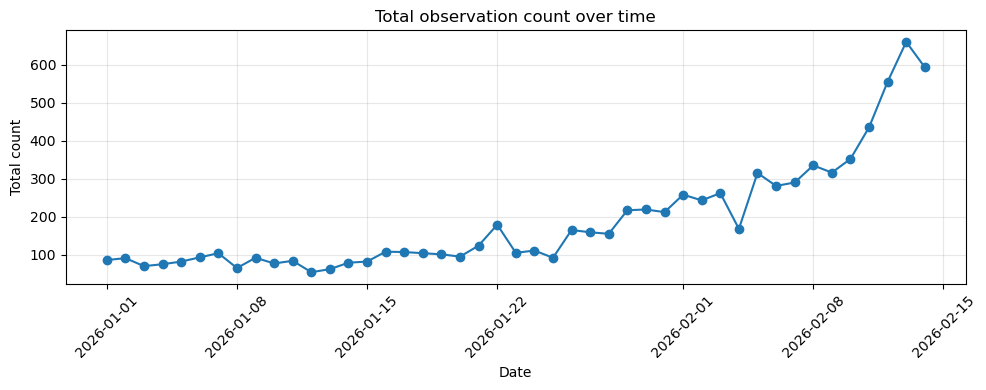

In [6]:
daily_total = daily.groupby("time_bin", as_index=False)["count"].sum()

plt.figure(figsize=(10, 4))
plt.plot(daily_total["time_bin"], daily_total["count"], marker="o")
plt.title("Total observation count over time")
plt.xlabel("Date")
plt.ylabel("Total count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Visualize cumulative spatial activity

The cumulative heatmap shows where activity concentrates over the full observation window.


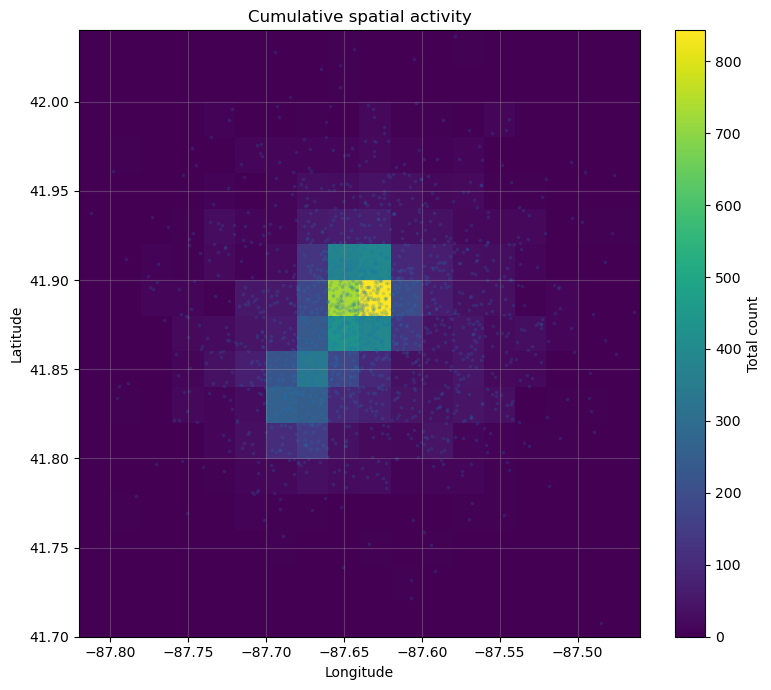

In [7]:
cell_totals = daily.groupby(["lat_bin", "lon_bin"], as_index=False)["count"].sum()

grid_counts = np.zeros((len(lat_edges) - 1, len(lon_edges) - 1))

for _, row in cell_totals.iterrows():
    i = int(row["lat_bin"])
    j = int(row["lon_bin"])
    if 0 <= i < grid_counts.shape[0] and 0 <= j < grid_counts.shape[1]:
        grid_counts[i, j] = row["count"]

extent = [lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]]

plt.figure(figsize=(8, 7))
plt.imshow(grid_counts, origin="lower", extent=extent, aspect="auto")
plt.colorbar(label="Total count")
plt.scatter(df["longitude"], df["latitude"], s=3, alpha=0.15)
plt.title("Cumulative spatial activity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


## 5. Estimate spatial density with KDE

A kernel density estimate gives a smooth view of where observations concentrate spatially. This is useful as a first-pass exploratory view before looking at discrete grid-cell statistics.


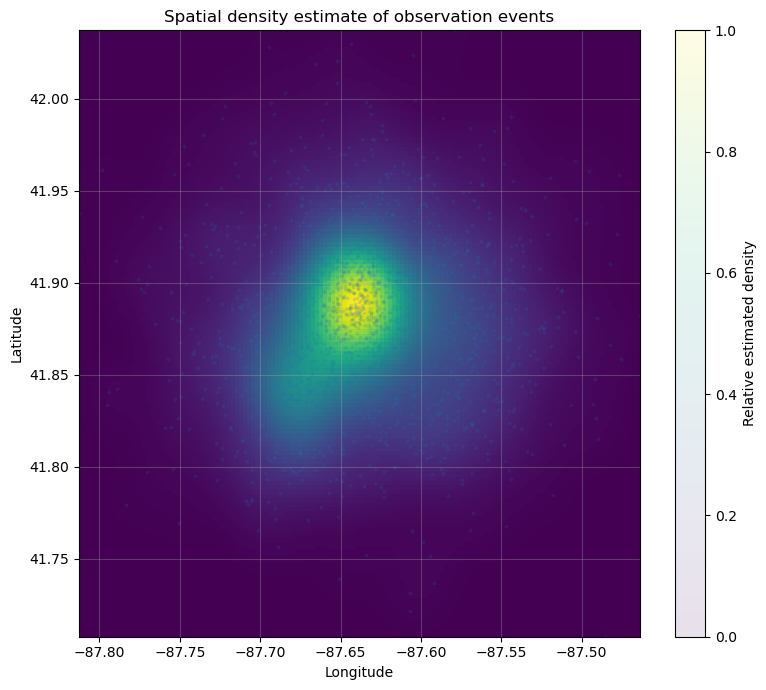

In [8]:
coords = df[["longitude", "latitude"]].to_numpy()

kde = KernelDensity(bandwidth=0.015, kernel="gaussian")
kde.fit(coords)

xx, yy = np.meshgrid(
    np.linspace(df["longitude"].min(), df["longitude"].max(), 140),
    np.linspace(df["latitude"].min(), df["latitude"].max(), 140),
)

grid_points = np.column_stack([xx.ravel(), yy.ravel()])
density = np.exp(kde.score_samples(grid_points)).reshape(xx.shape)
density = density / density.max()

plt.figure(figsize=(8, 7))
plt.imshow(
    density,
    origin="lower",
    extent=[df["longitude"].min(), df["longitude"].max(), df["latitude"].min(), df["latitude"].max()],
    aspect="auto",
)
plt.scatter(df["longitude"], df["latitude"], s=3, alpha=0.12)
plt.colorbar(label="Relative estimated density")
plt.title("Spatial density estimate of observation events")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


## 6. Compute a simple daily hotspot score

For each day, each grid cell's count is compared against the distribution of counts across all cells on the same day. This produces a lightweight daily z-score that highlights unusually active cells.

This is intentionally simple for a public demo. More formal workflows could use spatial statistics such as Getis-Ord Gi*, scan statistics, Bayesian models, or hierarchical spatiotemporal methods.


In [9]:
# Build a complete time-cell table so missing cells are treated as zero activity.
all_times = pd.date_range(df["time_bin"].min(), df["time_bin"].max(), freq="D")
all_cells = daily[["cell_id", "lat_bin", "lon_bin"]].drop_duplicates()

full_index = pd.MultiIndex.from_product(
    [all_times, all_cells["cell_id"]],
    names=["time_bin", "cell_id"],
)

cell_lookup = all_cells.set_index("cell_id")[["lat_bin", "lon_bin"]]

panel = (
    daily.set_index(["time_bin", "cell_id"])[["count"]]
    .reindex(full_index, fill_value=0)
    .reset_index()
    .join(cell_lookup, on="cell_id")
)

# Vectorized daily z-score calculation avoids groupby.apply warnings.
panel["daily_mean"] = panel.groupby("time_bin")["count"].transform("mean")
panel["daily_std"] = panel.groupby("time_bin")["count"].transform("std").fillna(0)
panel["daily_std"] = panel["daily_std"].replace(0, np.nan)

panel["z_score"] = ((panel["count"] - panel["daily_mean"]) / panel["daily_std"]).fillna(0)
panel["hotspot"] = panel["z_score"] > 2.0

panel.head()


,time_bin,cell_id,count,lat_bin,lon_bin,daily_mean,daily_std,z_score,hotspot
0,2026-01-01,10_10,2.0,10,10,0.477778,1.569455,0.969905,False
1,2026-01-01,10_11,1.0,10,11,0.477778,1.569455,0.332741,False
2,2026-01-01,10_12,1.0,10,12,0.477778,1.569455,0.332741,False
3,2026-01-01,10_8,2.0,10,8,0.477778,1.569455,0.969905,False
4,2026-01-01,10_9,3.0,10,9,0.477778,1.569455,1.607068,False


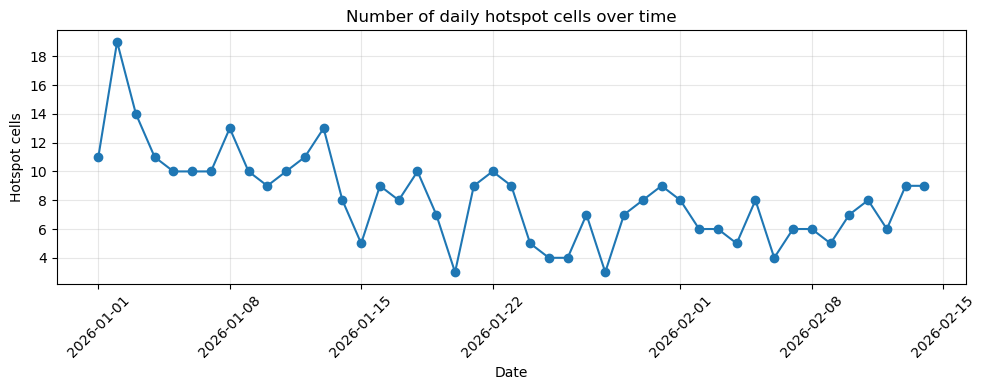

In [10]:
hotspot_days = (
    panel.groupby("time_bin", as_index=False)
    .agg(n_hotspots=("hotspot", "sum"), max_z=("z_score", "max"))
)

plt.figure(figsize=(10, 4))
plt.plot(hotspot_days["time_bin"], hotspot_days["n_hotspots"], marker="o")
plt.title("Number of daily hotspot cells over time")
plt.xlabel("Date")
plt.ylabel("Hotspot cells")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Plot daily hotspot scores for the strongest day

The map below shows cell-level z-scores on the day with the highest maximum hotspot score.


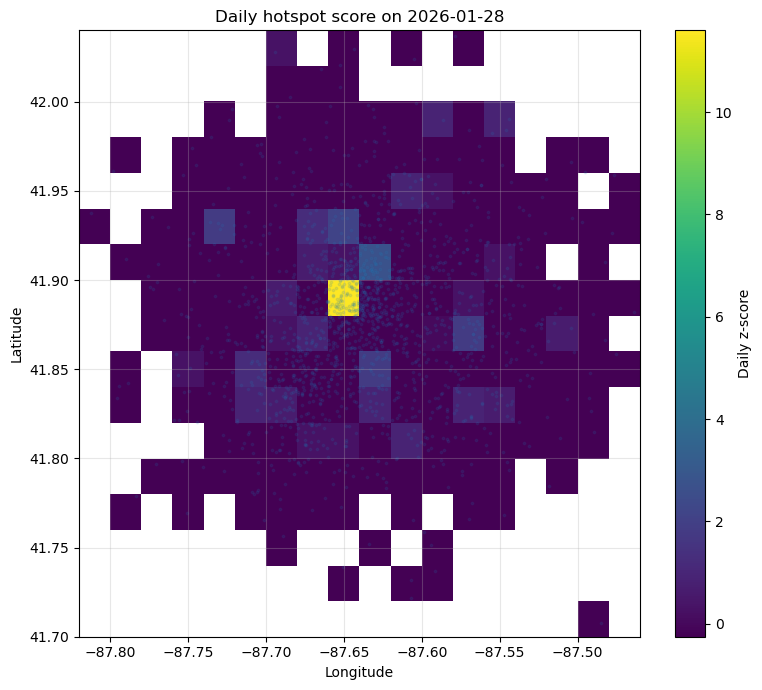

In [11]:
selected_day = hotspot_days.sort_values("max_z", ascending=False).iloc[0]["time_bin"]
selected = panel[panel["time_bin"] == selected_day]

z_grid = np.full((len(lat_edges) - 1, len(lon_edges) - 1), np.nan)

for _, row in selected.iterrows():
    i = int(row["lat_bin"])
    j = int(row["lon_bin"])
    z_grid[i, j] = row["z_score"]

plt.figure(figsize=(8, 7))
plt.imshow(z_grid, origin="lower", extent=extent, aspect="auto")
plt.colorbar(label="Daily z-score")
plt.scatter(df["longitude"], df["latitude"], s=3, alpha=0.12)
plt.title(f"Daily hotspot score on {pd.to_datetime(selected_day).date()}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


## 8. Track persistent buildup with a CUSUM-style score

A single spike can be useful, but persistent buildup is often more important for monitoring. The simple CUSUM-style score below accumulates positive deviations over time and resets when the signal drops.


In [12]:
def positive_cusum(values: np.ndarray, drift: float = 0.2) -> np.ndarray:
    """Compute a simple one-sided positive CUSUM score."""

    scores = np.zeros(len(values))

    for i in range(1, len(values)):
        scores[i] = max(0.0, scores[i - 1] + values[i] - drift)

    return scores


panel = panel.sort_values(["cell_id", "time_bin"]).copy()
panel["cusum_score"] = panel.groupby("cell_id")["z_score"].transform(
    lambda series: positive_cusum(series.to_numpy(), drift=0.2)
)

top_cells = (
    panel.groupby("cell_id", as_index=False)["cusum_score"]
    .max()
    .sort_values("cusum_score", ascending=False)
    .head(5)
)

top_cells


,cell_id,cusum_score
179,9_9,153.453393
178,9_8,126.437173
162,8_8,89.577220
15,10_9,72.863383
163,8_9,72.723881


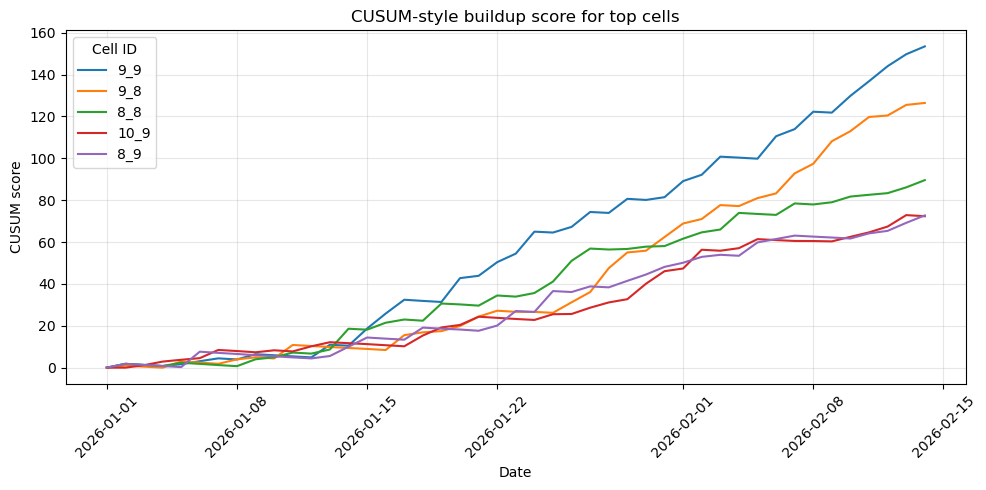

In [13]:
plt.figure(figsize=(10, 5))

for cell_id in top_cells["cell_id"]:
    cell_series = panel[panel["cell_id"] == cell_id]
    plt.plot(cell_series["time_bin"], cell_series["cusum_score"], label=cell_id)

plt.title("CUSUM-style buildup score for top cells")
plt.xlabel("Date")
plt.ylabel("CUSUM score")
plt.xticks(rotation=45)
plt.legend(title="Cell ID")
plt.tight_layout()
plt.show()


## Interpretation

The synthetic dataset contains one dominant spatial hotspot and a weaker secondary concentration. The KDE visualization highlights the main area of concentration, while the daily z-score analysis identifies short-term anomalous activity at the grid-cell level.

The CUSUM-style score helps distinguish persistent buildup from isolated spikes. This type of workflow can be useful when the main question is not only *where activity is high*, but also *where activity is becoming consistently elevated over time*.


## Possible extensions

Potential next steps for a production-quality workflow could include:

- replacing the simple latitude/longitude grid with projected geospatial cells
- using adaptive spatial clustering instead of fixed grid bins
- adding formal hotspot statistics such as Getis-Ord Gi*
- adding streaming anomaly detection for near-real-time monitoring
- adding Bayesian or hierarchical spatiotemporal models
- connecting the analysis to a lightweight dashboard or automated report


## Summary

This demo shows a compact end-to-end analysis workflow on safe synthetic data:

- spatial binning
- daily aggregation
- cumulative heatmaps
- KDE density estimation
- simple daily hotspot scoring
- CUSUM-style temporal buildup detection

The same structure can be adapted to many observational datasets where the core question is: where and when is activity becoming unusually concentrated?
